# Resort Churn — Neural Network with Optuna Hyperparameter Tuning

This is a derivative of `resort_nn.ipynb`. The data loading and preprocessing are identical;
the difference is that instead of picking the network's hyperparameters by hand we let
[**Optuna**](https://optuna.org/) search for them.

**What Optuna does in one paragraph:** you write an `objective(trial)` function that builds and
trains a model using values pulled from `trial.suggest_*` (e.g. `trial.suggest_float('lr', ...)`).
You return a number to minimize (or maximize). Optuna runs the objective many times, learning
from each trial's outcome to bias future trials toward promising regions of the search space
using a Tree-structured Parzen Estimator (TPE) by default. It also **prunes** bad trials early
so we don't waste compute training models that are obviously going to be worse than what we've
already seen.

**Search space (this notebook):**
- Hidden layer sizes (two layers)
- Dropout rate
- Learning rate (log-uniform)
- Weight decay (log-uniform)
- Batch size
- Optimizer (Adam vs AdamW)

**Objective:** maximize validation ROC AUC. AUC is a better target than accuracy for class-
imbalanced problems because it's threshold-independent.

## 1. Imports + setup

Same stack as before plus `optuna`. Uncomment the install line if needed.

In [1]:
# !pip install pandas numpy scikit-learn torch matplotlib optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import optuna
# Optuna logs every trial at INFO by default; bump to WARNING so the notebook output
# stays readable. Comment this out if you want to see per-trial chatter.
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Load + preprocess data

We load the **cleaned** train file from a local path. The cleaned file has already had
`BookingDate` removed, the `Room` string exploded into `RoomFloor` / `RoomNumber` / `RoomSide` /
`SharedRoom`, and missing `PromoCode` filled with `"NoPromoCode"` — so all we need to do here is
drop `GuestID` and separate the target.

We split into **train** (for fitting weights) and **val** (for Optuna to score trials). There is
no internal held-out test set anymore: the actual test data lives in a separate file
(`churn_test_cleaned.csv`) and is used at the very end of the notebook to produce `submission.csv`.


In [2]:
TRAIN_PATH = "/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union 2/Team-Union/Nick/churn_train_cleaned.csv"
TEST_PATH  = "/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union 2/Team-Union/Nick/churn_test_cleaned.csv"

train = pd.read_csv(TRAIN_PATH)

TARGET = "Churned"
y = train[TARGET].astype(np.float32).values
# Drop GuestID (just an identifier) and the target itself from the feature matrix.
X = train.drop(columns=[TARGET, "GuestID"])

# Auto-detect numeric vs categorical columns by dtype.
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols     = X.select_dtypes(include=[np.number]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,     numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

# Two-way split: train (~85%) and val (~15%). The val set is what Optuna scores against.
# The external test file is loaded later and is used purely to make the submission.
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# Fit the preprocessor on the training portion only (no leakage from val).
X_train = preprocessor.fit_transform(X_train_raw)
X_val   = preprocessor.transform(X_val_raw)
n_features = X_train.shape[1]

print(f"Splits - train: {X_train.shape}, val: {X_val.shape}")
print(f"Input features after encoding: {n_features}")
print(f"Numeric cols    ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical cols ({len(categorical_cols)}): {categorical_cols}")

# Cache tensors so every Optuna trial can reuse them without re-converting.
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)


Splits - train: (5910, 65), val: (1044, 65)
Input features after encoding: 65
Numeric cols    (12): ['AllInclusive', 'VIP', 'RoomService', 'Dining', 'Retail', 'Spa', 'Entertainment', 'LoyaltyPoints', 'SurveyScore', 'DaysSinceEmail', 'SharedRoom', 'RoomNumber']
Categorical cols (8): ['PromoCode', 'Region', 'PackageType', 'BookingChannel', 'AgeGroup', 'ReferralSource', 'RoomFloor', 'RoomSide']


## 3. Parametric model builder

We rewrite `ChurnMLP` to take hyperparameters as arguments. The Optuna objective will call this
with whatever values the sampler picks.

In [3]:
class ChurnMLP(nn.Module):
    def __init__(self, in_features, hidden1, hidden2, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.net(x)

## 4. The Optuna objective

Each trial:
1. Samples hyperparameters via `trial.suggest_*`.
2. Builds a model + optimizer with those choices.
3. Trains for a fixed number of epochs, computing val AUC each epoch.
4. **Reports** the val AUC to Optuna each epoch and checks `trial.should_prune()`. If the trial
   is clearly worse than other trials at the same epoch, the median pruner kills it early.
5. Returns the **best** val AUC seen — we don't want to penalize a trial for overfitting at the
   last epoch if it was great earlier (this is a lightweight stand-in for early stopping).

About the `suggest_*` calls:
- `suggest_int(name, low, high, step=)` — integer in `[low, high]`.
- `suggest_float(name, low, high, log=True)` — log-uniform sampling, the right choice for things
  like learning rates that span orders of magnitude.
- `suggest_categorical(name, [...])` — discrete choice.

In [4]:
TRIAL_EPOCHS = 20  # shorter than the final-model training; tuning is exploratory

def objective(trial: optuna.Trial) -> float:
    # ---- 1. Sample hyperparameters ----
    # Layer sizes — step=16 keeps the search space small enough to converge in a reasonable
    # number of trials. The second layer is bounded by the first so the network narrows toward
    # the output (a common, sensible MLP shape).
    hidden1 = trial.suggest_int("hidden1", 32, 256, step=16)
    hidden2 = trial.suggest_int("hidden2", 16, hidden1, step=16)

    dropout      = trial.suggest_float("dropout",      0.0, 0.5)
    lr           = trial.suggest_float("lr",           1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)
    batch_size   = trial.suggest_categorical("batch_size", [64, 128, 256])
    optim_name   = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])

    # ---- 2. Build model + optimizer ----
    model = ChurnMLP(n_features, hidden1, hidden2, dropout).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optim_cls = {"Adam": torch.optim.Adam, "AdamW": torch.optim.AdamW}[optim_name]
    optimizer = optim_cls(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Rebuild the DataLoader with the trial's batch size. We reuse the cached tensors.
    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True
    )

    # ---- 3. Train ----
    best_val_auc = 0.0
    for epoch in range(TRIAL_EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # ---- 4. Evaluate + maybe prune ----
        # Full-batch val pass; the val set is small enough that we don't need a loader.
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t.to(device))
            val_probs  = torch.sigmoid(val_logits).cpu().numpy().ravel()
        val_auc = roc_auc_score(y_val, val_probs)
        best_val_auc = max(best_val_auc, val_auc)

        # Report intermediate value to Optuna. The MedianPruner compares this against the median
        # of completed trials at the same step and may raise TrialPruned.
        trial.report(val_auc, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_auc

## 5. Run the Optuna study

- **Sampler**: TPE (Tree-structured Parzen Estimator), Optuna's default. It models the
  distribution of good vs bad trials and samples from where good ones tend to live.
- **Pruner**: `MedianPruner` — after the first 5 trials and 3 warm-up epochs per trial, kill any
  trial whose intermediate value is below the median of completed trials at the same step.
- **Direction**: `"maximize"` because higher AUC is better.

`N_TRIALS = 30` is a reasonable starting budget. Bump it for a more thorough search.

In [5]:
N_TRIALS = 60

sampler = optuna.samplers.TPESampler(seed=SEED)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
# show_progress_bar=True prints a tqdm bar; set it False if you're running headless / in CI.
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\nBest trial:")
print("  val AUC:", study.best_value)
print("  params :")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

# How many trials Optuna pruned vs ran to completion. A healthy pruner kills off a meaningful
# chunk — if it pruned almost nothing, consider tightening the pruner; if it pruned everything,
# loosen the warm-up.
n_pruned    = sum(t.state == optuna.trial.TrialState.PRUNED   for t in study.trials)
n_completed = sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials)
print(f"\nTrials: {n_completed} completed, {n_pruned} pruned, {len(study.trials)} total")

  0%|          | 0/60 [00:00<?, ?it/s]


Best trial:
  val AUC: 0.9112923352467079
  params :
    hidden1: 224
    hidden2: 128
    dropout: 0.29203124332975927
    lr: 0.0024028281478585055
    weight_decay: 0.00021369704304969835
    batch_size: 64
    optimizer: Adam

Trials: 25 completed, 35 pruned, 60 total


## 6. Inspect the study

A few diagnostic plots:
- **Optimization history** — best score over trials. Should trend up (we're maximizing).
- **Parameter importances** — Optuna fits a fANOVA model to estimate which hyperparameters
  mattered most for the objective. Cheap and useful for narrowing future search spaces.

In [6]:
# Trials as a DataFrame for ad-hoc analysis.
trials_df = study.trials_dataframe(attrs=("number", "value", "state", "params"))
trials_df.head(10)

,number,value,state,params_batch_size,params_dropout,params_hidden1,params_hidden2,params_lr,params_optimizer,params_weight_decay
0,0,0.906829,COMPLETE,256,0.365997,112,112,0.001575,AdamW,4.207989e-07
1,1,0.899860,COMPLETE,256,0.416221,32,32,0.000266,Adam,5.337033e-07
2,2,0.907956,COMPLETE,64,0.146072,176,32,0.000540,Adam,6.672367e-06
3,3,0.908969,COMPLETE,64,0.032526,176,32,0.007903,Adam,7.286654e-04
4,4,0.908866,COMPLETE,64,0.017194,48,32,0.006586,Adam,1.084226e-06
5,5,0.907604,COMPLETE,64,0.469749,256,208,0.006161,AdamW,2.463769e-05
6,6,0.882214,PRUNED,256,0.414369,112,32,0.000517,AdamW,1.329652e-06
7,7,0.903123,PRUNED,128,0.002761,208,48,0.004275,Adam,6.720930e-05
8,8,0.885443,PRUNED,128,0.165449,224,144,0.000134,Adam,1.753595e-06
9,9,0.901900,PRUNED,128,0.380393,48,48,0.001326,AdamW,1.213022e-04


/var/folders/gs/161p8px5645bt7rwtlw7t_w40000gn/T/ipykernel_29837/3848698782.py:9: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


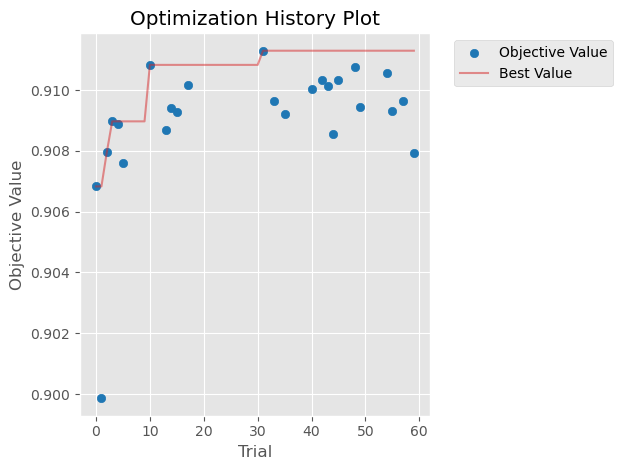

/var/folders/gs/161p8px5645bt7rwtlw7t_w40000gn/T/ipykernel_29837/3848698782.py:12: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


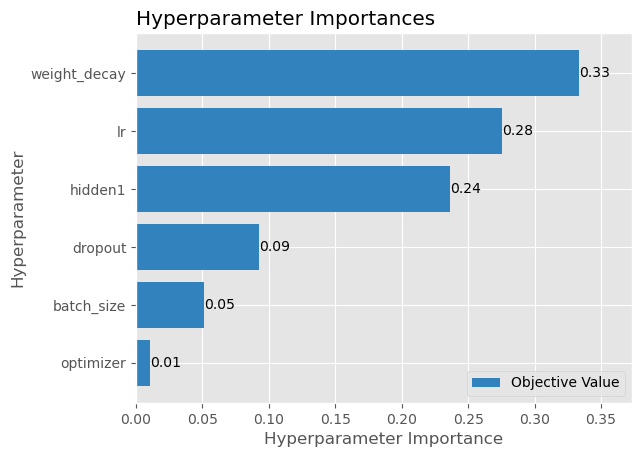

In [7]:
# Optuna ships matplotlib-based plots in optuna.visualization.matplotlib. If the matplotlib
# submodule isn't available in your install, the equivalent plotly versions live in
# optuna.visualization (no `.matplotlib` suffix).
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
)

plot_optimization_history(study)
plt.show()

plot_param_importances(study)
plt.show()

## 7. Retrain the best configuration on train+val

Tuning is done. Standard practice now:
1. Take the best hyperparameters Optuna found.
2. **Refit the preprocessor on the full train+val set** so we don't waste 15% of our labeled data,
   and refit the model on the same combined data. (We must refit the preprocessor too — otherwise
   the one-hot encoder might be missing categories that only appear in the val portion.)
3. Train for a few more epochs than tuning used (trials were intentionally short).


In [8]:
best = study.best_params
FINAL_EPOCHS = 40

# Refit the preprocessor on the full train+val data, then transform.
X_full_raw = pd.concat([X_train_raw, X_val_raw], axis=0)
y_full     = np.concatenate([y_train, y_val], axis=0)

final_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_cols),
])
X_full = final_preprocessor.fit_transform(X_full_raw)
n_features_final = X_full.shape[1]

X_full_t = torch.tensor(X_full, dtype=torch.float32)
y_full_t = torch.tensor(y_full, dtype=torch.float32).unsqueeze(1)

full_loader = DataLoader(
    TensorDataset(X_full_t, y_full_t), batch_size=best["batch_size"], shuffle=True
)

final_model = ChurnMLP(
    n_features_final, best["hidden1"], best["hidden2"], best["dropout"]
).to(device)

optim_cls = {"Adam": torch.optim.Adam, "AdamW": torch.optim.AdamW}[best["optimizer"]]
optimizer = optim_cls(
    final_model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"]
)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(FINAL_EPOCHS):
    final_model.train()
    running = 0.0
    for xb, yb in full_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(final_model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d} | train_loss={running / len(X_full_t):.4f}")


Epoch 01 | train_loss=0.4423
Epoch 05 | train_loss=0.3453
Epoch 10 | train_loss=0.3209
Epoch 15 | train_loss=0.2920
Epoch 20 | train_loss=0.2604
Epoch 25 | train_loss=0.2344
Epoch 30 | train_loss=0.2141
Epoch 35 | train_loss=0.1987
Epoch 40 | train_loss=0.1827


## 8. Predict on the external test file and write `submission.csv`

The cleaned test file has the same columns as the cleaned train file **except** for the `Churned`
target (that's what we're predicting). We:
1. Load it.
2. Strip `GuestID` for the feature matrix, but keep it aside for the submission.
3. Transform with the **same fitted preprocessor** used for the final model (`final_preprocessor`)
   so the column order and one-hot encoding match exactly.
4. Run the model, threshold at 0.5, attach the predictions to the `GuestID` column, and write
   `submission.csv`.


In [9]:
test = pd.read_csv(TEST_PATH)

# Keep GuestID for the submission file; drop it from the feature matrix.
test_features = test.drop(columns=["GuestID"])

# Transform using the preprocessor we just fit on full train+val.
# handle_unknown="ignore" on the one-hot encoder means any unseen category in the test file
# becomes an all-zero row for that feature group rather than crashing.
X_test_final = final_preprocessor.transform(test_features)
X_test_final_t = torch.tensor(X_test_final, dtype=torch.float32)

final_model.eval()
with torch.no_grad():
    test_probs = torch.sigmoid(final_model(X_test_final_t.to(device))).cpu().numpy().ravel()
test_preds = (test_probs >= 0.5).astype(int)

# Build submission: GuestIDs from the test file + predicted Churned column.
submission = test[["GuestID"]].copy()
submission["Churned"] = test_preds
submission.to_csv("submission.csv", index=False)

print(f"Wrote submission.csv with {len(submission)} rows.")
print(f"Predicted churn rate: {test_preds.mean():.3f}")
print(submission.head())


Wrote submission.csv with 1739 rows.
Predicted churn rate: 0.466
   GuestID  Churned
0   154038        1
1   620160        1
2   655103        0
3   126993        1
4   635228        1


## Notes / further ideas

- **Persist the study.** Pass `storage="sqlite:///resort_optuna.db"` and `study_name=...` to
  `create_study` (with `load_if_exists=True`) so you can resume or share studies across runs.
- **Parallelism.** Optuna can run trials in parallel — either with multiple processes pointing
  at the same SQLite/RDB storage, or with `n_jobs > 1` (be careful: PyTorch threading + Python's
  GIL means `n_jobs` only helps if the bottleneck releases the GIL).
- **Cross-validation per trial.** Right now each trial scores on a single val split, which is
  noisy. Wrapping the inner training in K-fold CV gives a more stable signal at K× the cost.
- **More aggressive pruning.** `HyperbandPruner` is a strong default for budgets > a few dozen
  trials — it allocates more epochs to promising trials instead of treating every trial equally.
- **Expand the search space carefully.** Wider spaces need more trials. Use parameter-importance
  plots to spot which knobs barely matter and freeze them.